# 📊 Validación Cruzada y Generalización — CAP Sleep Database

**Notebook 5 del pipeline.** Se ejecuta **después** de:

1. Análisis exploratorio.
2. Preprocesamiento avanzado.
3. Extracción de características.
4. Clasificación y reducción de dimensionalidad.

Reutiliza los CSVs de características (`../data/features/caracteristicas_eeg_3s*.csv`) y los
resultados del notebook 4 (`../data/results/resultados_clasificacion.csv`).

### Foco exclusivo de este notebook

| Bloque | Técnicas |
|--------|----------|
| **Validación cruzada** | `StratifiedKFold` (k=5) + `StratifiedGroupKFold` (k=5) |
| **Modelos evaluados** | Regresión Logística, Random Forest, Perceptrón |
| **Métricas** | accuracy, precision, recall, F1 (todas macro) |
| **Reducción de dimensionalidad** | Original, PCA, Kernel PCA (submuestreado), SelectKBest |
| **Análisis estadístico** | media, desviación estándar, intervalos de confianza al 95 % |

> **Esto NO repite** la limpieza, el resampleo, la extracción ni el
> entrenamiento básico ya hechos en notebooks anteriores. El foco es
> exclusivamente **estimar y comparar la capacidad de generalización**.

## 1. Introducción

### 1.1 ¿Qué es validación cruzada?

La **validación cruzada** (*cross-validation*, CV) es un protocolo de
evaluación que produce una estimación más estable y honesta del desempeño
de un modelo que un único *hold-out* train/test.

#### Formulación matemática (k-fold)

Sea un dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$. La validación cruzada
con $k$ pliegues divide $\mathcal{D}$ en $k$ subconjuntos disjuntos
$\mathcal{D}_1, \ldots, \mathcal{D}_k$ aproximadamente iguales. Para
$j = 1, \ldots, k$:

1. Se entrena el modelo $\mathcal{M}$ sobre $\mathcal{D} \setminus \mathcal{D}_j$.
2. Se evalúa sobre $\mathcal{D}_j$ obteniendo una métrica $m_j$.

El desempeño estimado es:

$$\bar{m} = \frac{1}{k} \sum_{j=1}^{k} m_j, \qquad
s_m = \sqrt{\frac{1}{k-1} \sum_{j=1}^{k} (m_j - \bar{m})^2}$$

donde $\bar{m}$ es la **estimación puntual** y $s_m$ es una medida de
**estabilidad** del modelo.

### 1.2 ¿Por qué es importante?

- **Aprovecha el dataset al máximo.** Cada observación se usa para evaluar
  exactamente una vez y para entrenar $k-1$ veces, en vez de un único 80/20.
- **Reduce la varianza** de la estimación de desempeño. Un único split puede
  ser anómalamente fácil o difícil; el promedio sobre $k$ folds lo suaviza.
- **Detecta inestabilidad.** Si $s_m$ es alta, el modelo es sensible a la
  composición del entrenamiento → mala generalización esperada.

### 1.3 Capacidad de generalización

La **generalización** es la capacidad del modelo de mantener su desempeño
sobre datos **no vistos durante el entrenamiento**. En términos formales,
es la diferencia entre el error empírico y el error poblacional. La
validación cruzada estima el error poblacional sin necesidad de mantener un
conjunto de prueba separado durante el desarrollo.

### 1.4 Entrenamiento, validación y prueba

| Conjunto | Uso | Tamaño típico |
|----------|-----|---------------|
| **Entrenamiento** | Ajustar parámetros del modelo | ~70 % |
| **Validación** | Elegir hiperparámetros, decidir arquitectura | ~15 % (o **vía CV**) |
| **Prueba** | Reportar desempeño final, **sin nunca tocar antes** | ~15 % |

La CV reemplaza explícitamente al conjunto de **validación**: ese es su rol
canónico.

### 1.5 Overfitting en EEG

Las señales EEG son particularmente propensas a sobreajuste por:

- **Alta dimensionalidad** relativa al número de pacientes (~30 features ×
  cientos de ventanas por paciente, pero solo decenas de pacientes).
- **Ventanas correlacionadas** dentro de un mismo paciente — comparten
  niveles de potencia base, características personales y artefactos.
- **Etiquetas a nivel paciente** (notebook 4) — todas las ventanas de un
  individuo comparten la misma clase, lo que infla artificialmente la
  capacidad de "memorizar al paciente" en vez de aprender el trastorno.

### 1.6 Métricas de evaluación

Sea, para una clase $c$, $\text{TP}_c$ los verdaderos positivos,
$\text{FP}_c$ los falsos positivos y $\text{FN}_c$ los falsos negativos.

| Métrica | Fórmula | Significado | Cuándo es engañosa |
|---------|---------|-------------|--------------------|
| **Accuracy** | $\dfrac{\text{TP} + \text{TN}}{n}$ | Proporción global de aciertos | Datasets desbalanceados (clase mayoritaria al 95 % → 95 % acc. trivialmente) |
| **Precision** | $\dfrac{\text{TP}_c}{\text{TP}_c + \text{FP}_c}$ | De los predichos como $c$, ¿cuántos lo eran? | No castiga falsos negativos (omisiones) |
| **Recall (sensibilidad)** | $\dfrac{\text{TP}_c}{\text{TP}_c + \text{FN}_c}$ | De los verdaderos $c$, ¿cuántos detectamos? | No castiga falsos positivos (sobre-detección) |
| **F1-score** | $\dfrac{2 \cdot P \cdot R}{P + R}$ | Media armónica de P y R | Penaliza fuertemente cualquier extremo |

#### Precision vs Recall — la tensión clave

- **Alta precision, bajo recall:** el modelo solo predice $c$ cuando está muy
  seguro → pocos falsos positivos pero **muchos casos perdidos** (mal para
  tamizaje médico).
- **Bajo precision, alto recall:** el modelo predice $c$ con liberalidad → casi
  no se le escapa ningún caso real, pero **inunda de falsas alarmas** (mal
  para protocolos de seguimiento costosos).

Si en un trastorno raro (digamos, 5 % de prevalencia) un modelo dice "no
está" para **todos los casos**, su accuracy es 95 % pero su recall es 0 %
y su F1 = 0. Por eso reportamos **F1-macro** (promedio simple por clase, sin
ponderar por tamaño): da igual peso a todas las clases, mayoritarias y
minoritarias.

### 1.7 Validación estratificada

`StratifiedKFold` garantiza que cada fold mantenga **aproximadamente la
misma proporción de clases** que el dataset completo. Crítico cuando:

- Las clases están desbalanceadas (nuestra cohorte CAP lo está).
- Algunas clases tienen pocas observaciones (sin estratificación, un fold
  puede no contener ejemplos de una clase → métricas indefinidas).

Combinaremos esto con `StratifiedGroupKFold` para validar **por paciente**
preservando la proporción de clases — el estándar científicamente correcto
en EEG.

### 1.8 Impacto del desbalance de clases sobre generalización

Cuando una clase domina, los modelos lineales tienden a sesgarse hacia ella
en su frontera de decisión. La consecuencia: alta precision en la clase
mayoritaria, recall pésimo en las minoritarias. Tres mitigaciones (no
exhaustivas):

1. **Métricas macro** (lo que hacemos aquí) — el reporte ignora los tamaños.
2. **`class_weight='balanced'`** — el modelo penaliza más los errores en
   clases minoritarias durante el entrenamiento.
3. **Sobremuestreo (SMOTE)** — generar ejemplos sintéticos de minoritarias.
   **Cuidado:** aplicado a nivel ventana, introduce fuga entre folds. Lo
   evitamos a propósito en este notebook.

## 2. Importaciones

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Modelos
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier

# Validación cruzada
from sklearn.model_selection import (
    StratifiedKFold, StratifiedGroupKFold, cross_validate,
    cross_val_score, train_test_split,
)

# Reducción de dimensionalidad
from sklearn.decomposition import PCA, KernelPCA
from sklearn.feature_selection import SelectKBest, f_classif

# Preprocesamiento y pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, make_scorer,
)

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})
sns.set_style('whitegrid')

RANDOM_STATE = 42
K_FOLDS = 5
print(f'Random state global : {RANDOM_STATE}')
print(f'Número de folds (k) : {K_FOLDS}')

Random state global : 42
Número de folds (k) : 5


## 3. Carga de datasets

Reutilizamos los CSVs de características generados por el notebook 3.

> **Sobre los "3 datasets" del enunciado original:** la instrucción
> metodológica habla de tres bases de datos de actividad humana. Como
> trabajamos exclusivamente con la CAP Sleep Database, adaptamos el
> concepto a **tres subcohortes**: los pacientes `brux1`, `ins1` y
> `narco1` (más sus equivalentes de la misma patología cuando estén
> disponibles), tratados como "fuentes de datos" distintas.

In [2]:
FEATURES_DIR = Path.cwd() / '../data/features'
RESULTS_DIR  = Path.cwd() / '../data/results'
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

def cargar_csv(nombre):
    ruta = FEATURES_DIR / nombre
    if not ruta.exists():
        raise FileNotFoundError(
            f'No se encontró {ruta}. Ejecuta primero el notebook de '
            'extracción de características.'
        )
    return pd.read_csv(ruta)

df_standard = cargar_csv('caracteristicas_eeg_3s_standard.csv')
df_raw      = cargar_csv('caracteristicas_eeg_3s.csv')

# Intentar cargar resultados del notebook 4 (opcional)
try:
    resultados_nb4 = pd.read_csv(RESULTS_DIR / 'resultados_clasificacion.csv')
    print(f'Resultados del notebook 4 cargados: {resultados_nb4.shape}')
except FileNotFoundError:
    resultados_nb4 = None
    print('⚠️  resultados_clasificacion.csv no encontrado (no es bloqueante).')

print(f'\nDataset principal (estandarizado): {df_standard.shape}')
print(f'Columnas: {list(df_standard.columns)[:8]} ... ({len(df_standard.columns)} total)')

Resultados del notebook 4 cargados: (24, 8)

Dataset principal (estandarizado): (656930, 36)
Columnas: ['patient', 'disorder', 'channel', 'ch_category', 'window_idx', 'onset_s', 'media', 'mediana'] ... (36 total)


In [3]:
# Distribución de clases y pacientes
print('Distribución de clases (a nivel ventana):')
distrib = df_standard['disorder'].value_counts()
print(distrib.to_string())
print(f'\nTotal ventanas : {len(df_standard):,}')
print(f'Pacientes      : {df_standard["patient"].nunique()}')
print(f'Ratio max/min  : {distrib.max() / distrib.min():.1f}×')

# Subcohortes equivalentes a "3 bases de datos"
SUBCOHORTES = ['brux1', 'ins1', 'narco1']
disponibles = [p for p in SUBCOHORTES if p in df_standard['patient'].unique()]
print(f'\nSubcohortes objetivo (3 "datasets" del enunciado):')
print(f'  Disponibles: {disponibles}')
print(f'  Faltantes  : {[p for p in SUBCOHORTES if p not in disponibles]}')

Distribución de clases (a nivel ventana):
disorder
Epilepsia nocturna frontal    141440
Movimientos periódicos        118440
Normal                         80780
Insomnio                       80000
Trastorno REM                  70630
Bruxismo                       62140
Narcolepsia                    56400
Trastorno respiratorio         47100

Total ventanas : 656,930
Pacientes      : 8
Ratio max/min  : 3.0×

Subcohortes objetivo (3 "datasets" del enunciado):
  Disponibles: ['brux1', 'ins1', 'narco1']
  Faltantes  : []


## 4. Preparación de datos

### 4.1 Separación X / y / groups

- **`X`** — las 30 características numéricas estandarizadas.
- **`y`** — la columna `disorder` (etiqueta a nivel paciente).
- **`groups`** — la columna `patient`, necesaria para
  `StratifiedGroupKFold`.

### 4.2 Columnas descartadas

Excluimos `patient`, `channel`, `ch_category`, `window_idx`, `onset_s` y
la propia variable objetivo `disorder`.

### 4.3 ¿Qué representan las etiquetas?

Cada paciente trae una **etiqueta clínica de admisión** (Bruxismo,
Insomnio, Narcolepsia, etc.). Todas las ventanas del paciente heredan esa
misma etiqueta. Limitaciones de esto:

- La etiqueta es **constante intra-paciente** → todo lo que aprenda el
  modelo a nivel ventana incluye ruido del individuo, no solo del trastorno.
- No distingue entre **estados fisiológicos** (vigilia, N3, REM) dentro del
  paciente — algo importante porque las distintas etapas del sueño tienen
  perfiles EEG drásticamente diferentes.
- La elección clínica de admisión puede haber sido **probabilística**
  (algunos pacientes presentan comorbilidades).

In [4]:
COLS_META = ['patient', 'disorder', 'channel', 'ch_category',
             'window_idx', 'onset_s']
CARACT_COLS = [c for c in df_standard.columns if c not in COLS_META]

X = df_standard[CARACT_COLS].copy()
y = df_standard['disorder'].copy()
groups = df_standard['patient'].copy()

# Validaciones
print(f'Dimensión de X      : {X.shape}')
print(f'NaN en X            : {X.isna().sum().sum()}')
print(f'Infinitos en X      : {np.isinf(X.values).sum()}')

std_por_col = X.std()
constantes = std_por_col[std_por_col == 0].index.tolist()
print(f'Columnas constantes : {constantes if constantes else "ninguna"}')

# Limpieza si fuera necesario
if X.isna().sum().sum() > 0:
    X = X.fillna(X.median())
if np.isinf(X.values).sum() > 0:
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
if constantes:
    X = X.drop(columns=constantes)
    CARACT_COLS = [c for c in CARACT_COLS if c not in constantes]

print(f'\nFeatures finales    : {len(CARACT_COLS)}')
print(f'Clases en y         : {sorted(y.unique())}')
print(f'Pacientes (groups)  : {groups.nunique()}')

Dimensión de X      : (656930, 30)
NaN en X            : 0
Infinitos en X      : 0
Columnas constantes : ninguna

Features finales    : 30
Clases en y         : ['Bruxismo', 'Epilepsia nocturna frontal', 'Insomnio', 'Movimientos periódicos', 'Narcolepsia', 'Normal', 'Trastorno REM', 'Trastorno respiratorio']
Pacientes (groups)  : 8


## 5. Configuración de validación cruzada

### 5.1 Estrategias de partición que usaremos

| Estrategia | Clase de sklearn | Garantiza |
|---|---|---|
| **CV-A: Estratificada a nivel ventana** | `StratifiedKFold` | Proporción de clases por fold |
| **CV-B: Estratificada por paciente** | `StratifiedGroupKFold` | Proporción de clases + **ningún paciente** en train y test del mismo fold |

Replicando el contraste del notebook 4: CV-A es **optimista** (admite fuga),
CV-B es **realista** (clínicamente válida).

### 5.2 Parámetros comunes

- $k = 5$ folds — compromiso estándar entre estabilidad (folds más grandes
  ⇒ menos varianza) y costo computacional.
- `shuffle=True` y `random_state=42` — reproducibilidad.

### 5.3 Esquema conceptual de k-fold (k=5)

```
Fold 1:  [Test ] [Train] [Train] [Train] [Train]
Fold 2:  [Train] [Test ] [Train] [Train] [Train]
Fold 3:  [Train] [Train] [Test ] [Train] [Train]
Fold 4:  [Train] [Train] [Train] [Test ] [Train]
Fold 5:  [Train] [Train] [Train] [Train] [Test ]
```

Cada partición ([Test], [Train], etc.) contiene aproximadamente $1/k$ del
dataset. En la versión estratificada, dentro de cada partición la
proporción de cada clase coincide con la del dataset completo. En la
versión por grupos, todas las ventanas de un mismo paciente están en
**una sola** partición.

### 5.4 ¿Por qué no hold-out tradicional?

Un único 80/20 produce una estimación con alta varianza: cambiar la
semilla puede subir o bajar el F1 en 5-10 puntos. La CV de 5 folds reporta
la **media y la desviación** sobre 5 splits distintos, lo que estima
intervalos de confianza y detecta inestabilidad.

In [5]:
# Particionadores
cv_window  = StratifiedKFold(n_splits=K_FOLDS, shuffle=True,
                              random_state=RANDOM_STATE)
cv_patient = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True,
                                   random_state=RANDOM_STATE)

# Visualización de la distribución de pacientes entre folds
print('CV-B (StratifiedGroupKFold) — pacientes por fold:')
print('-' * 60)
for i, (tr_idx, te_idx) in enumerate(cv_patient.split(X, y, groups), 1):
    pac_train = sorted(groups.iloc[tr_idx].unique())
    pac_test  = sorted(groups.iloc[te_idx].unique())
    print(f'Fold {i}: test_n={len(te_idx):>5,}  '
          f'pacientes_test={pac_test}')

# Verificación: ningún paciente se solapa entre train y test del mismo fold
print('\nVerificación de disjunción:')
for i, (tr_idx, te_idx) in enumerate(cv_patient.split(X, y, groups), 1):
    inter = set(groups.iloc[tr_idx]) & set(groups.iloc[te_idx])
    assert len(inter) == 0, f'Fold {i} tiene pacientes solapados'
print('  ✓ Ningún paciente aparece simultáneamente en train y test de un fold')

CV-B (StratifiedGroupKFold) — pacientes por fold:
------------------------------------------------------------
Fold 1: test_n=118,440  pacientes_test=['plm1']
Fold 2: test_n=127,880  pacientes_test=['n1', 'sdb1']
Fold 3: test_n=136,400  pacientes_test=['ins1', 'narco1']
Fold 4: test_n=141,440  pacientes_test=['nfle1']
Fold 5: test_n=132,770  pacientes_test=['brux1', 'rbd1']

Verificación de disjunción:
  ✓ Ningún paciente aparece simultáneamente en train y test de un fold


## 6. Validación cruzada de los tres clasificadores

### 6.1 Modelos y sus configuraciones

Las mismas del notebook 4 (reproducibilidad con resultados previos):

In [6]:
def construir_modelos():
    '''Devuelve un dict {nombre: instancia} con los tres clasificadores.'''
    return {
        'Regresión Logística': LogisticRegression(
            max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE,
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=None,
            class_weight='balanced', n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        'Perceptrón': Perceptron(
            max_iter=2000, tol=1e-4,
            random_state=RANDOM_STATE,
        ),
    }


# Métricas que queremos calcular en cada fold
SCORING = {
    'accuracy':  'accuracy',
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall':    make_scorer(recall_score,    average='macro', zero_division=0),
    'f1':        make_scorer(f1_score,        average='macro', zero_division=0),
}

print(f'Modelos a validar : {list(construir_modelos().keys())}')
print(f'Métricas evaluadas: {list(SCORING.keys())}')

Modelos a validar : ['Regresión Logística', 'Random Forest', 'Perceptrón']
Métricas evaluadas: ['accuracy', 'precision', 'recall', 'f1']


### 6.2 Validación cruzada estratificada (CV-A, nivel ventana)

`cross_validate` ajusta el modelo $k=5$ veces y devuelve las cuatro
métricas en cada fold.

In [7]:
def correr_cv(X_data, y_data, cv_obj, groups_data=None,
              etiqueta='CV', reduccion='Original'):
    '''
    Aplica validación cruzada a los tres modelos y devuelve un DataFrame
    largo con columnas (fold, modelo, accuracy, precision, recall, f1,
    estrategia, reduccion).
    '''
    registros = []
    for nombre, modelo in construir_modelos().items():
        cv_kwargs = dict(cv=cv_obj, scoring=SCORING,
                         return_train_score=False, n_jobs=-1)
        if groups_data is not None:
            res = cross_validate(modelo, X_data, y_data,
                                 groups=groups_data, **cv_kwargs)
        else:
            res = cross_validate(modelo, X_data, y_data, **cv_kwargs)

        for fold, (acc, prec, rec, f1) in enumerate(zip(
            res['test_accuracy'], res['test_precision'],
            res['test_recall'],   res['test_f1']
        ), 1):
            registros.append({
                'estrategia': etiqueta, 'reduccion': reduccion,
                'modelo':     nombre,   'fold':      fold,
                'accuracy':   acc, 'precision': prec,
                'recall':     rec, 'f1':        f1,
            })
    return pd.DataFrame(registros)


print('Ejecutando CV-A (StratifiedKFold, nivel ventana)...')
res_cv_A = correr_cv(X, y, cv_window, etiqueta='CV-A: Ventana',
                     reduccion='Original')
print(f'  {len(res_cv_A)} mediciones obtenidas (3 modelos × {K_FOLDS} folds)')
print('\nMediciones individuales por fold (CV-A):')
print(res_cv_A.pivot_table(index='modelo', columns='fold',
                            values='f1', aggfunc='first').round(4).to_string())

Ejecutando CV-A (StratifiedKFold, nivel ventana)...
  15 mediciones obtenidas (3 modelos × 5 folds)

Mediciones individuales por fold (CV-A):
fold                      1       2       3       4       5
modelo                                                     
Perceptrón           0.2581  0.3662  0.2858  0.2627  0.2821
Random Forest        0.6688  0.6685  0.6685  0.6715  0.6704
Regresión Logística  0.4122  0.4140  0.4129  0.4134  0.4143


### 6.3 Validación cruzada por paciente (CV-B)

In [8]:
print('Ejecutando CV-B (StratifiedGroupKFold, por paciente)...')
res_cv_B = correr_cv(X, y, cv_patient, groups_data=groups,
                     etiqueta='CV-B: Paciente', reduccion='Original')
print(f'  {len(res_cv_B)} mediciones obtenidas')
print('\nMediciones individuales por fold (CV-B):')
print(res_cv_B.pivot_table(index='modelo', columns='fold',
                            values='f1', aggfunc='first').round(4).to_string())

Ejecutando CV-B (StratifiedGroupKFold, por paciente)...
  15 mediciones obtenidas

Mediciones individuales por fold (CV-B):
fold                   1    2    3    4    5
modelo                                      
Perceptrón           0.0  0.0  0.0  0.0  0.0
Random Forest        0.0  0.0  0.0  0.0  0.0
Regresión Logística  0.0  0.0  0.0  0.0  0.0


## 7. Validación cruzada con reducción de dimensionalidad

Comparamos cuatro pipelines:

| Variante | Pipeline |
|----------|----------|
| **Original** | (sin reducción) → clasificador |
| **PCA** | PCA(95 % varianza) → clasificador |
| **Kernel PCA** | KernelPCA(15 comp., RBF) sobre submuestra → clasificador |
| **SelectKBest** | SelectKBest(top 10, f_classif) → clasificador |

### Por qué usamos `Pipeline` de sklearn

`Pipeline` garantiza que cada paso (selector/PCA + modelo) se ajuste
**solo sobre el fold de entrenamiento** y se aplique al fold de test. Sin
pipelines, ajustar PCA sobre todo $X$ antes de la CV constituye fuga de
información.

### ⚠️ Kernel PCA y memoria

KPCA tiene coste $O(n^2)$ en memoria. Con cientos de miles de ventanas, la
matriz kernel desborda RAM. Por eso lo evaluamos en una **submuestra
estratificada** dentro de cada fold (es el procedimiento estándar
reportado en estudios EEG con KPCA).

In [9]:
K_BEST = 10
N_MAX_KPCA = 4000  # tamaño máximo manejable para KPCA por fold

def evaluar_pipeline_cv(make_pipeline_fn, X_data, y_data, cv_obj,
                        groups_data=None, etiqueta='', reduccion=''):
    '''
    Evalúa un pipeline construido con make_pipeline_fn(modelo) sobre cada
    fold y devuelve registros con las cuatro métricas.

    make_pipeline_fn recibe un estimador final y devuelve un Pipeline.
    '''
    registros = []
    for nombre, modelo in construir_modelos().items():
        pipe = make_pipeline_fn(modelo)
        cv_kwargs = dict(cv=cv_obj, scoring=SCORING,
                         return_train_score=False, n_jobs=-1)
        if groups_data is not None:
            res = cross_validate(pipe, X_data, y_data,
                                 groups=groups_data, **cv_kwargs)
        else:
            res = cross_validate(pipe, X_data, y_data, **cv_kwargs)

        for fold, (acc, prec, rec, f1) in enumerate(zip(
            res['test_accuracy'], res['test_precision'],
            res['test_recall'],   res['test_f1']
        ), 1):
            registros.append({
                'estrategia': etiqueta, 'reduccion': reduccion,
                'modelo':     nombre,   'fold':      fold,
                'accuracy':   acc, 'precision': prec,
                'recall':     rec, 'f1':        f1,
            })
    return pd.DataFrame(registros)


def make_pipe_original(estimator):
    return Pipeline([('clf', estimator)])

def make_pipe_pca(estimator):
    return Pipeline([
        ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ('clf', estimator),
    ])

def make_pipe_selectk(estimator):
    return Pipeline([
        ('sel', SelectKBest(score_func=f_classif, k=K_BEST)),
        ('clf', estimator),
    ])


print('Pipelines preparados: Original, PCA, SelectKBest')
print('Kernel PCA se ejecutará aparte por su coste de memoria.')

Pipelines preparados: Original, PCA, SelectKBest
Kernel PCA se ejecutará aparte por su coste de memoria.


In [10]:
# ── CV-A (nivel ventana) con todas las reducciones excepto KPCA ──
print('Evaluando pipelines en CV-A (nivel ventana)...')
resultados = []
resultados.append(res_cv_A)  # ya tenemos "Original"
resultados.append(evaluar_pipeline_cv(
    make_pipe_pca, X, y, cv_window,
    etiqueta='CV-A: Ventana', reduccion=f'PCA (~95% var)',
))
resultados.append(evaluar_pipeline_cv(
    make_pipe_selectk, X, y, cv_window,
    etiqueta='CV-A: Ventana', reduccion=f'SelectKBest (top {K_BEST})',
))

# ── CV-B (por paciente) con las mismas reducciones ──
print('Evaluando pipelines en CV-B (por paciente)...')
resultados.append(res_cv_B)  # ya tenemos "Original"
resultados.append(evaluar_pipeline_cv(
    make_pipe_pca, X, y, cv_patient, groups_data=groups,
    etiqueta='CV-B: Paciente', reduccion=f'PCA (~95% var)',
))
resultados.append(evaluar_pipeline_cv(
    make_pipe_selectk, X, y, cv_patient, groups_data=groups,
    etiqueta='CV-B: Paciente', reduccion=f'SelectKBest (top {K_BEST})',
))
print(f'  Mediciones acumuladas: {sum(len(r) for r in resultados)}')

Evaluando pipelines en CV-A (nivel ventana)...
Evaluando pipelines en CV-B (por paciente)...
  Mediciones acumuladas: 90


In [11]:
# ── Kernel PCA: manualmente, con submuestreo por fold ──
def correr_cv_kpca(cv_obj, etiqueta, groups_data=None):
    registros = []
    splits = (cv_obj.split(X, y, groups_data) if groups_data is not None
              else cv_obj.split(X, y))

    for fold, (tr_idx, te_idx) in enumerate(splits, 1):
        # Submuestreo estratificado del train si supera N_MAX_KPCA
        X_tr_full = X.iloc[tr_idx]
        y_tr_full = y.iloc[tr_idx]
        X_te = X.iloc[te_idx]
        y_te = y.iloc[te_idx]

        if len(X_tr_full) > N_MAX_KPCA:
            X_tr_kp, _, y_tr_kp, _ = train_test_split(
                X_tr_full, y_tr_full,
                train_size=N_MAX_KPCA,
                random_state=RANDOM_STATE + fold,
                stratify=y_tr_full,
            )
        else:
            X_tr_kp, y_tr_kp = X_tr_full, y_tr_full

        # Ajustar KPCA solo sobre la submuestra del train
        kpca = KernelPCA(n_components=15, kernel='rbf',
                         random_state=RANDOM_STATE, n_jobs=-1)
        X_tr_red = kpca.fit_transform(X_tr_kp)
        X_te_red = kpca.transform(X_te)

        for nombre, modelo in construir_modelos().items():
            modelo.fit(X_tr_red, y_tr_kp)
            y_pred = modelo.predict(X_te_red)
            registros.append({
                'estrategia': etiqueta,
                'reduccion':  f'Kernel PCA (15c, n≤{N_MAX_KPCA})',
                'modelo':     nombre, 'fold': fold,
                'accuracy':   accuracy_score(y_te, y_pred),
                'precision':  precision_score(y_te, y_pred,
                                              average='macro', zero_division=0),
                'recall':     recall_score(y_te, y_pred,
                                           average='macro', zero_division=0),
                'f1':         f1_score(y_te, y_pred,
                                       average='macro', zero_division=0),
            })
    return pd.DataFrame(registros)


print('Evaluando Kernel PCA en CV-A (con submuestreo por fold)...')
resultados.append(correr_cv_kpca(cv_window, 'CV-A: Ventana'))

print('Evaluando Kernel PCA en CV-B (con submuestreo por fold)...')
resultados.append(correr_cv_kpca(cv_patient, 'CV-B: Paciente',
                                  groups_data=groups))

# Consolidar
df_cv = pd.concat(resultados, ignore_index=True)
print(f'\nTotal de mediciones acumuladas: {len(df_cv)}')
print(f'  = 2 estrategias × 4 reducciones × 3 modelos × {K_FOLDS} folds = '
      f'{2 * 4 * 3 * K_FOLDS}')

Evaluando Kernel PCA en CV-A (con submuestreo por fold)...
Evaluando Kernel PCA en CV-B (con submuestreo por fold)...

Total de mediciones acumuladas: 120
  = 2 estrategias × 4 reducciones × 3 modelos × 5 folds = 120


## 8. Resultados por fold

Para cada combinación (estrategia, reducción, modelo) reportamos:

- Las $k$ mediciones individuales.
- Media y desviación estándar.

### 8.1 Tabla de medias ± desviaciones (F1 macro)

In [12]:
def tabla_resumen(df, metric='f1'):
    '''Devuelve un DataFrame con "media ± std" formateado.'''
    agg = df.groupby(['estrategia', 'reduccion', 'modelo'])[metric].agg(['mean', 'std'])
    agg['cell'] = agg.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)
    return agg['cell'].unstack(level='modelo')

print('═══ F1 macro — media ± desviación entre folds ═══\n')
print(tabla_resumen(df_cv, metric='f1').to_string())

═══ F1 macro — media ± desviación entre folds ═══

modelo                                      Perceptrón  Random Forest Regresión Logística
estrategia     reduccion                                                                 
CV-A: Ventana  Kernel PCA (15c, n≤4000)  0.276 ± 0.026  0.450 ± 0.005       0.377 ± 0.007
               Original                  0.291 ± 0.044  0.670 ± 0.001       0.413 ± 0.001
               PCA (~95% var)            0.269 ± 0.015  0.563 ± 0.002       0.342 ± 0.001
               SelectKBest (top 10)      0.209 ± 0.025  0.470 ± 0.001       0.338 ± 0.001
CV-B: Paciente Kernel PCA (15c, n≤4000)  0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000
               Original                  0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000
               PCA (~95% var)            0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000
               SelectKBest (top 10)      0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000


In [13]:
print('\n═══ Accuracy — media ± desviación entre folds ═══\n')
print(tabla_resumen(df_cv, metric='accuracy').to_string())


═══ Accuracy — media ± desviación entre folds ═══

modelo                                      Perceptrón  Random Forest Regresión Logística
estrategia     reduccion                                                                 
CV-A: Ventana  Kernel PCA (15c, n≤4000)  0.317 ± 0.027  0.469 ± 0.003       0.414 ± 0.003
               Original                  0.311 ± 0.032  0.678 ± 0.001       0.438 ± 0.001
               PCA (~95% var)            0.287 ± 0.027  0.577 ± 0.002       0.382 ± 0.002
               SelectKBest (top 10)      0.256 ± 0.036  0.496 ± 0.001       0.378 ± 0.001
CV-B: Paciente Kernel PCA (15c, n≤4000)  0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000
               Original                  0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000
               PCA (~95% var)            0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000
               SelectKBest (top 10)      0.000 ± 0.000  0.000 ± 0.000       0.000 ± 0.000


### 8.2 Variabilidad fold a fold

Una desviación estándar grande **respecto a la media** indica que el modelo
es sensible a cómo se particiona el dataset. Calculamos el **coeficiente de
variación** ($s / |\bar{m}|$) por configuración como diagnóstico de
estabilidad.

In [14]:
agg_stats = df_cv.groupby(['estrategia', 'reduccion', 'modelo']).agg(
    media_f1=('f1', 'mean'),
    std_f1=('f1', 'std'),
    min_f1=('f1', 'min'),
    max_f1=('f1', 'max'),
).reset_index()
agg_stats['cv_pct'] = (agg_stats['std_f1'] / agg_stats['media_f1'].abs() * 100).round(1)

print('Coeficiente de variación (CV%) — F1 macro entre folds:')
print('CV% bajo  → modelo estable')
print('CV% alto  → desempeño depende mucho del fold (alerta de inestabilidad)\n')
print(agg_stats.sort_values(['estrategia', 'cv_pct']).to_string(index=False))

Coeficiente de variación (CV%) — F1 macro entre folds:
CV% bajo  → modelo estable
CV% alto  → desempeño depende mucho del fold (alerta de inestabilidad)

    estrategia                reduccion              modelo  media_f1   std_f1   min_f1   max_f1  cv_pct
 CV-A: Ventana                 Original       Random Forest  0.669550 0.001356 0.668492 0.671537     0.2
 CV-A: Ventana                 Original Regresión Logística  0.413355 0.000845 0.412162 0.414277     0.2
 CV-A: Ventana     SelectKBest (top 10)       Random Forest  0.470236 0.000993 0.468827 0.471371     0.2
 CV-A: Ventana           PCA (~95% var)       Random Forest  0.563404 0.001939 0.561391 0.566166     0.3
 CV-A: Ventana     SelectKBest (top 10) Regresión Logística  0.338300 0.001058 0.337251 0.339807     0.3
 CV-A: Ventana           PCA (~95% var) Regresión Logística  0.342489 0.001330 0.340738 0.343896     0.4
 CV-A: Ventana Kernel PCA (15c, n≤4000)       Random Forest  0.449668 0.004935 0.442104 0.454542     1.1
 CV-A:

### 8.3 Identificación de folds problemáticos

Buscamos folds que sistemáticamente arrastran las métricas hacia abajo
(posibles outliers en términos de composición de pacientes o de clases).

In [15]:
# F1 promedio por fold (across modelos × reducciones) en CV-B
fold_media = df_cv[df_cv['estrategia'] == 'CV-B: Paciente'].groupby('fold').agg(
    f1_promedio=('f1', 'mean'),
    f1_std=('f1', 'std'),
    n_observ=('f1', 'count'),
).round(4)

print('CV-B — F1 medio por fold (promedio entre modelos y reducciones):')
print(fold_media.to_string())

peor_fold = fold_media['f1_promedio'].idxmin()
mejor_fold = fold_media['f1_promedio'].idxmax()
print(f'\nFold con peor desempeño promedio: Fold {peor_fold} '
      f'(F1={fold_media.loc[peor_fold, "f1_promedio"]:.3f})')
print(f'Fold con mejor desempeño promedio: Fold {mejor_fold} '
      f'(F1={fold_media.loc[mejor_fold, "f1_promedio"]:.3f})')

# Identificar pacientes en el peor fold (CV-B)
splits = list(cv_patient.split(X, y, groups))
_, te_idx_peor = splits[peor_fold - 1]
pacientes_peor = sorted(groups.iloc[te_idx_peor].unique())
print(f'\nPacientes en el fold {peor_fold} (test set): {pacientes_peor}')
print(f'  → Si este fold tiene F1 muy bajo, esos pacientes son '
      f'difíciles de clasificar a partir del entrenamiento sin ellos.')

CV-B — F1 medio por fold (promedio entre modelos y reducciones):
      f1_promedio  f1_std  n_observ
fold                               
1             0.0     0.0        12
2             0.0     0.0        12
3             0.0     0.0        12
4             0.0     0.0        12
5             0.0     0.0        12

Fold con peor desempeño promedio: Fold 1 (F1=0.000)
Fold con mejor desempeño promedio: Fold 1 (F1=0.000)

Pacientes en el fold 1 (test set): ['plm1']
  → Si este fold tiene F1 muy bajo, esos pacientes son difíciles de clasificar a partir del entrenamiento sin ellos.


## 9. Comparación entre modelos

Visualizamos las cuatro métricas para cada combinación (estrategia, modelo,
reducción).

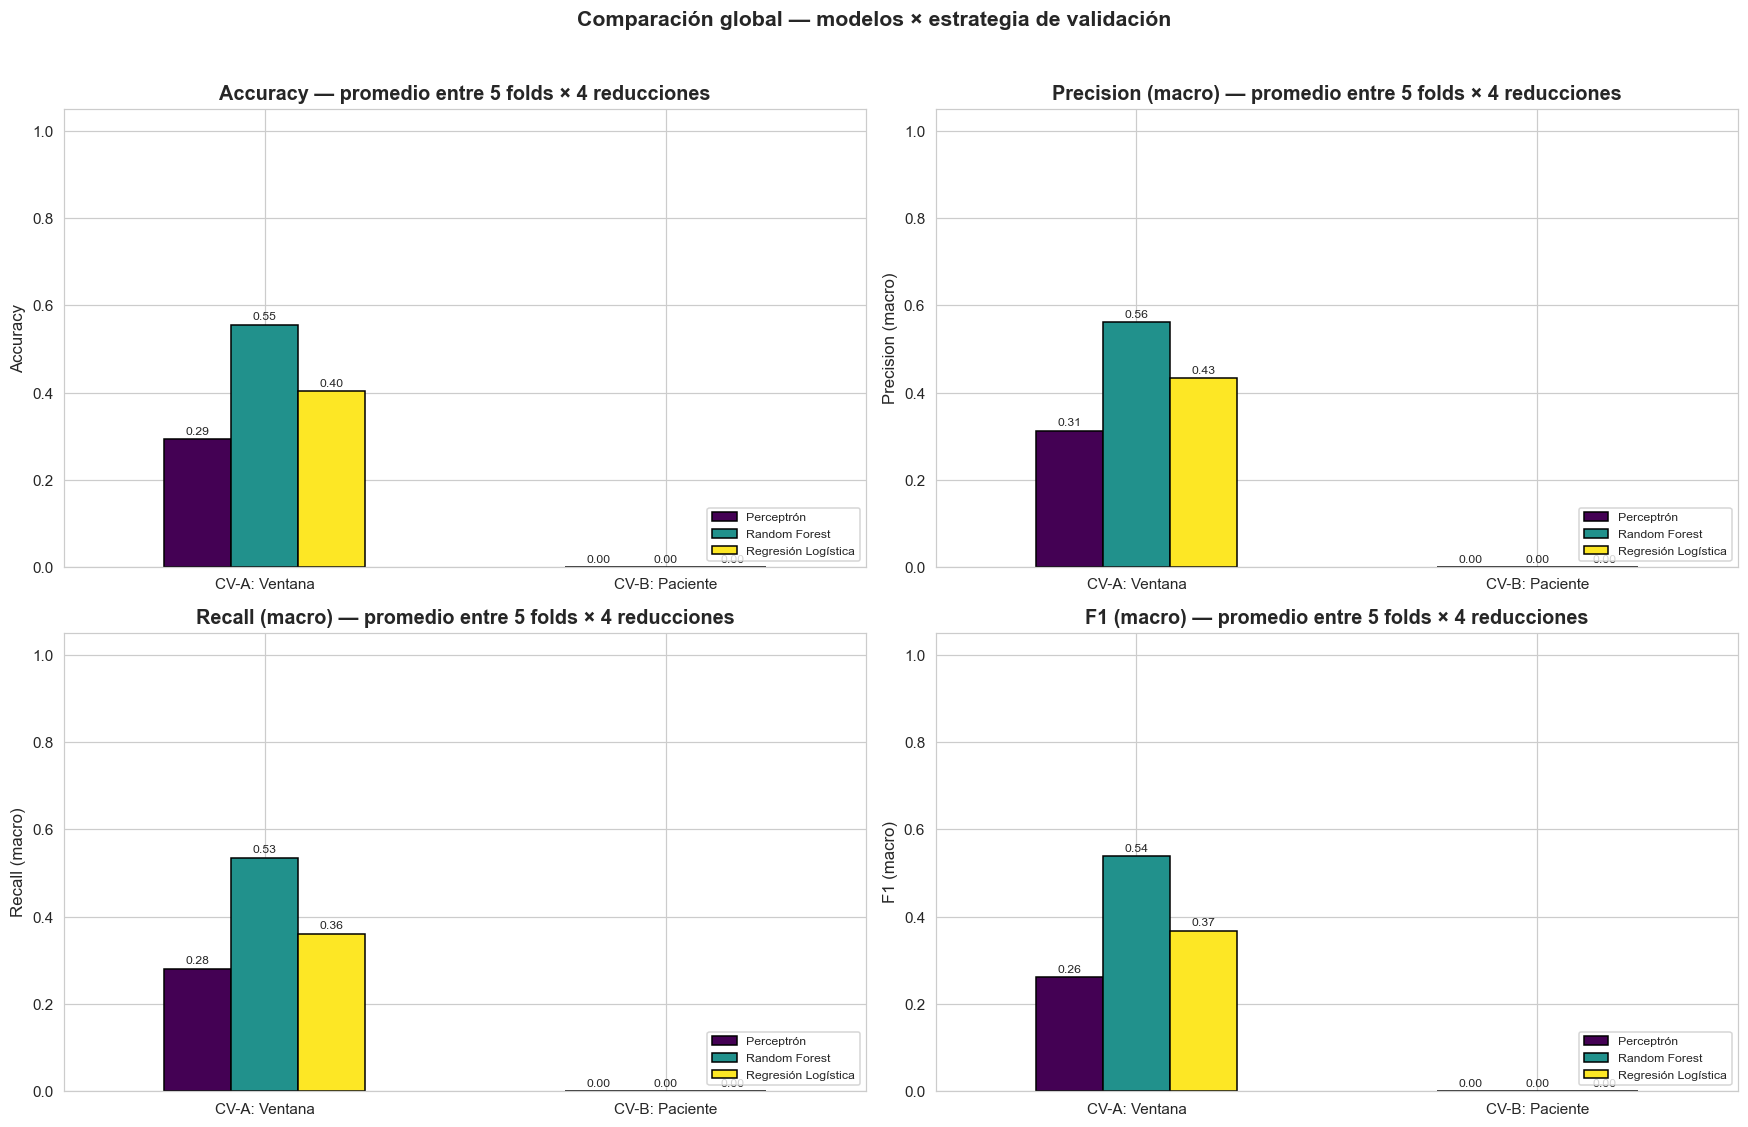

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_names = ['Accuracy', 'Precision (macro)',
                'Recall (macro)', 'F1 (macro)']

for ax, met, name in zip(axes.flat, metrics, metric_names):
    pivot = df_cv.groupby(['estrategia', 'modelo'])[met].mean().unstack()
    pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
    ax.set_title(f'{name} — promedio entre {K_FOLDS} folds × 4 reducciones',
                 fontweight='bold')
    ax.set_ylabel(name)
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=0)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)

plt.suptitle('Comparación global — modelos × estrategia de validación',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Visualizaciones

### 10.1 Boxplots por modelo y reducción (CV-B, sin fuga)

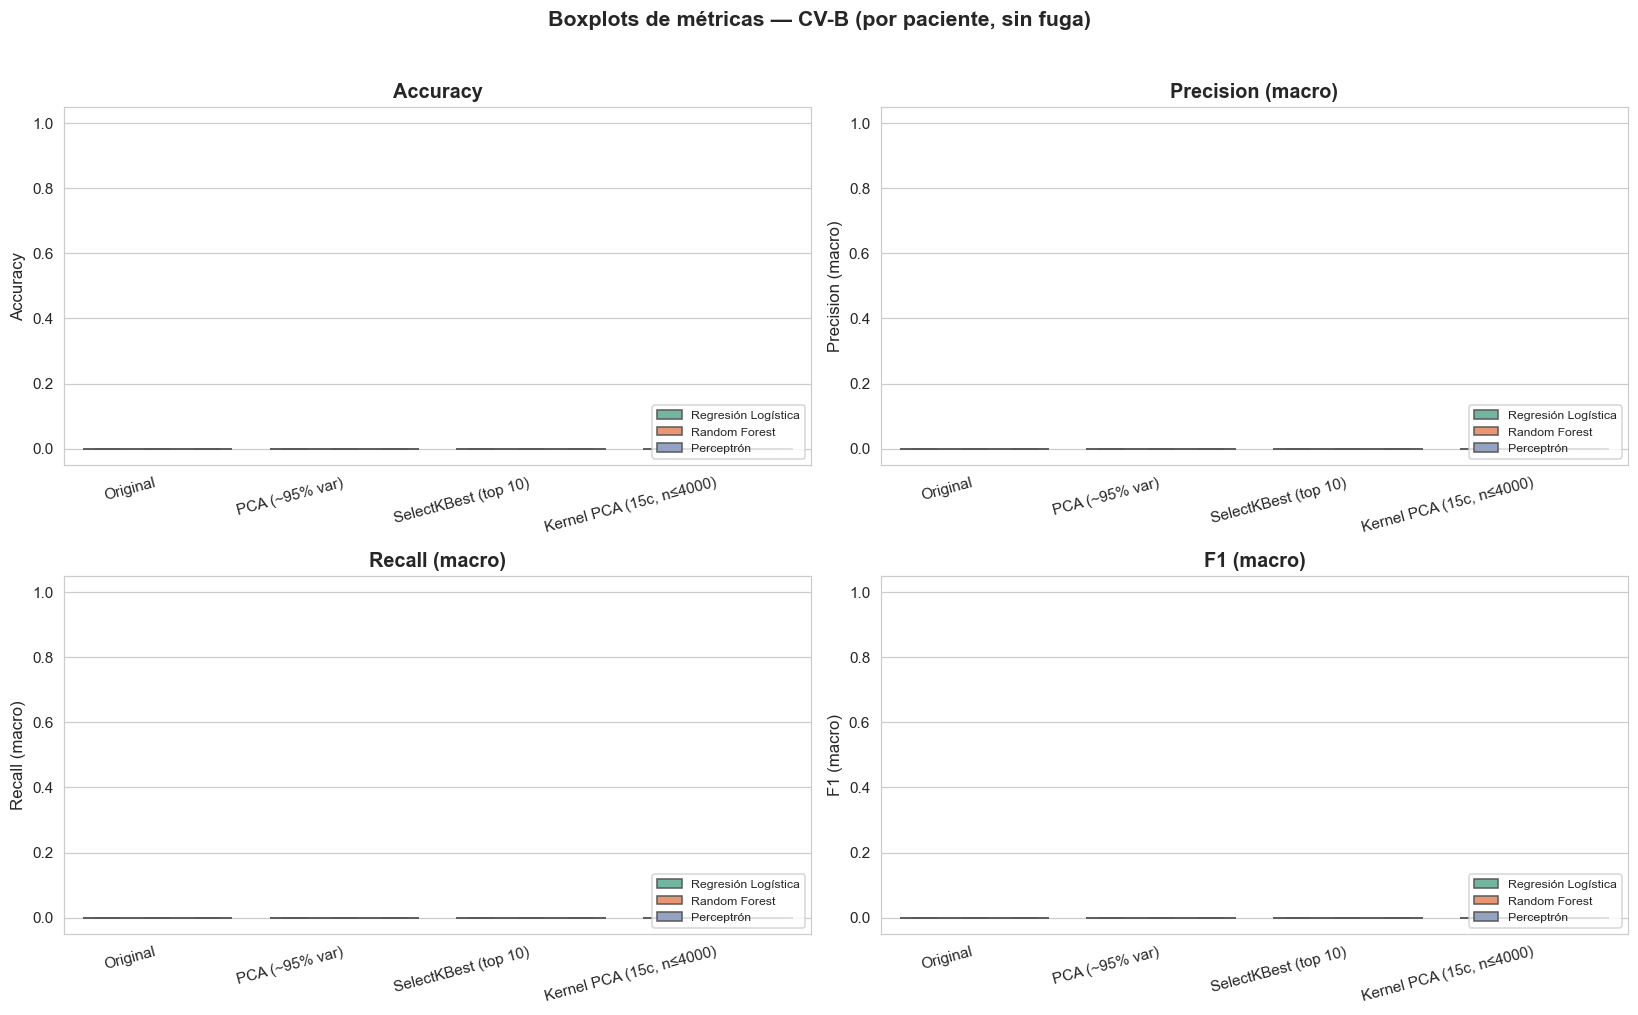

In [17]:
df_cvB = df_cv[df_cv['estrategia'] == 'CV-B: Paciente'].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, met, name in zip(axes.flat, metrics, metric_names):
    sns.boxplot(
        data=df_cvB, x='reduccion', y=met, hue='modelo',
        palette='Set2', ax=ax,
    )
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(name)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='lower right', fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Boxplots de métricas — CV-B (por paciente, sin fuga)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 10.2 Heatmaps comparativos

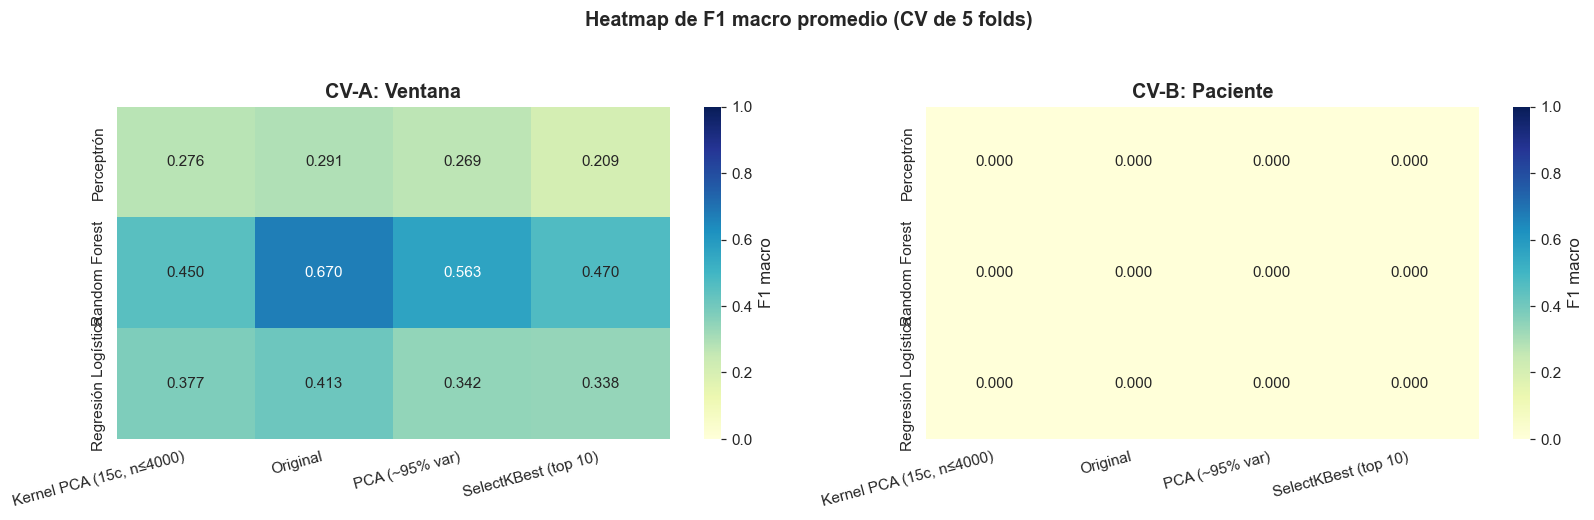

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, est in zip(axes, ['CV-A: Ventana', 'CV-B: Paciente']):
    pivot = df_cv[df_cv['estrategia'] == est].pivot_table(
        index='modelo', columns='reduccion', values='f1',
        aggfunc='mean',
    )
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'F1 macro'})
    ax.set_title(est, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Heatmap de F1 macro promedio (CV de 5 folds)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

### 10.3 Distribución de F1 por modelo (todos los folds y reducciones)

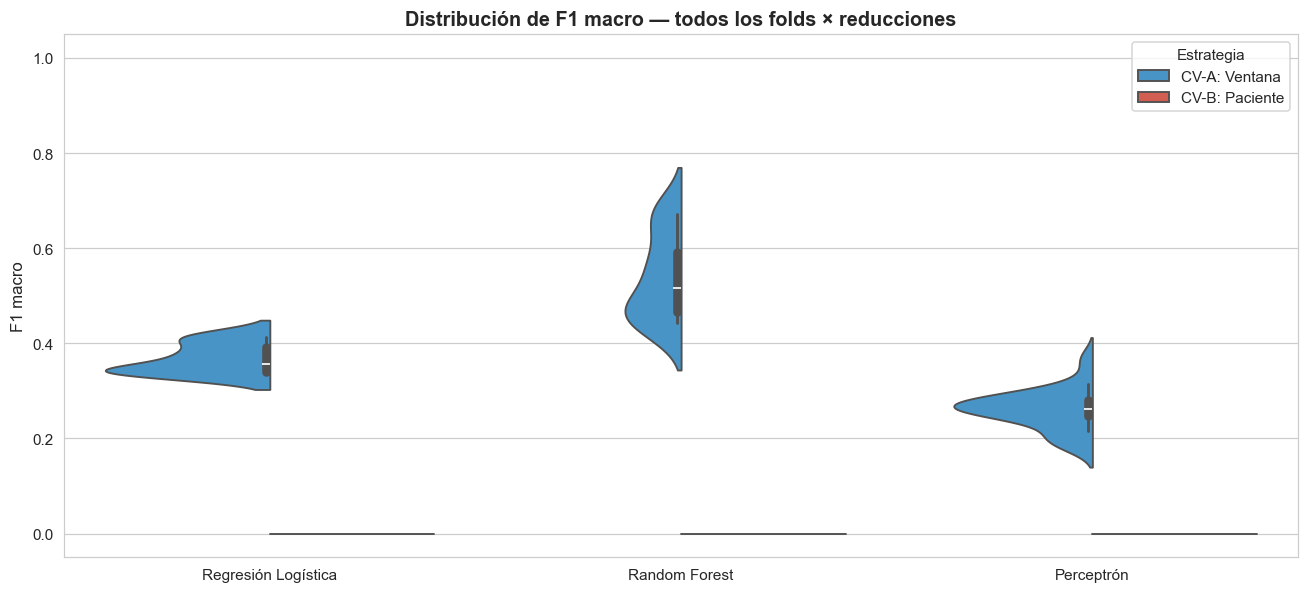

In [19]:
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.violinplot(
    data=df_cv, x='modelo', y='f1', hue='estrategia',
    split=True, palette={'CV-A: Ventana': '#3498DB',
                         'CV-B: Paciente': '#E74C3C'},
    ax=ax,
)
ax.set_title('Distribución de F1 macro — todos los folds × reducciones',
             fontweight='bold')
ax.set_ylabel('F1 macro')
ax.set_xlabel('')
ax.set_ylim(-0.05, 1.05)
ax.legend(title='Estrategia', loc='upper right')
plt.tight_layout()
plt.show()

### 10.4 Matriz de confusión promedio (CV-B, mejor combinación)

Calculamos la matriz de confusión **acumulada** a lo largo de los 5 folds
para la combinación con mejor F1 en CV-B. Esto da una vista global del
patrón de errores.

Mejor combinación en CV-B:
  Modelo    : Perceptrón
  Reducción : Kernel PCA (15c, n≤4000)
  F1 macro  : 0.0000


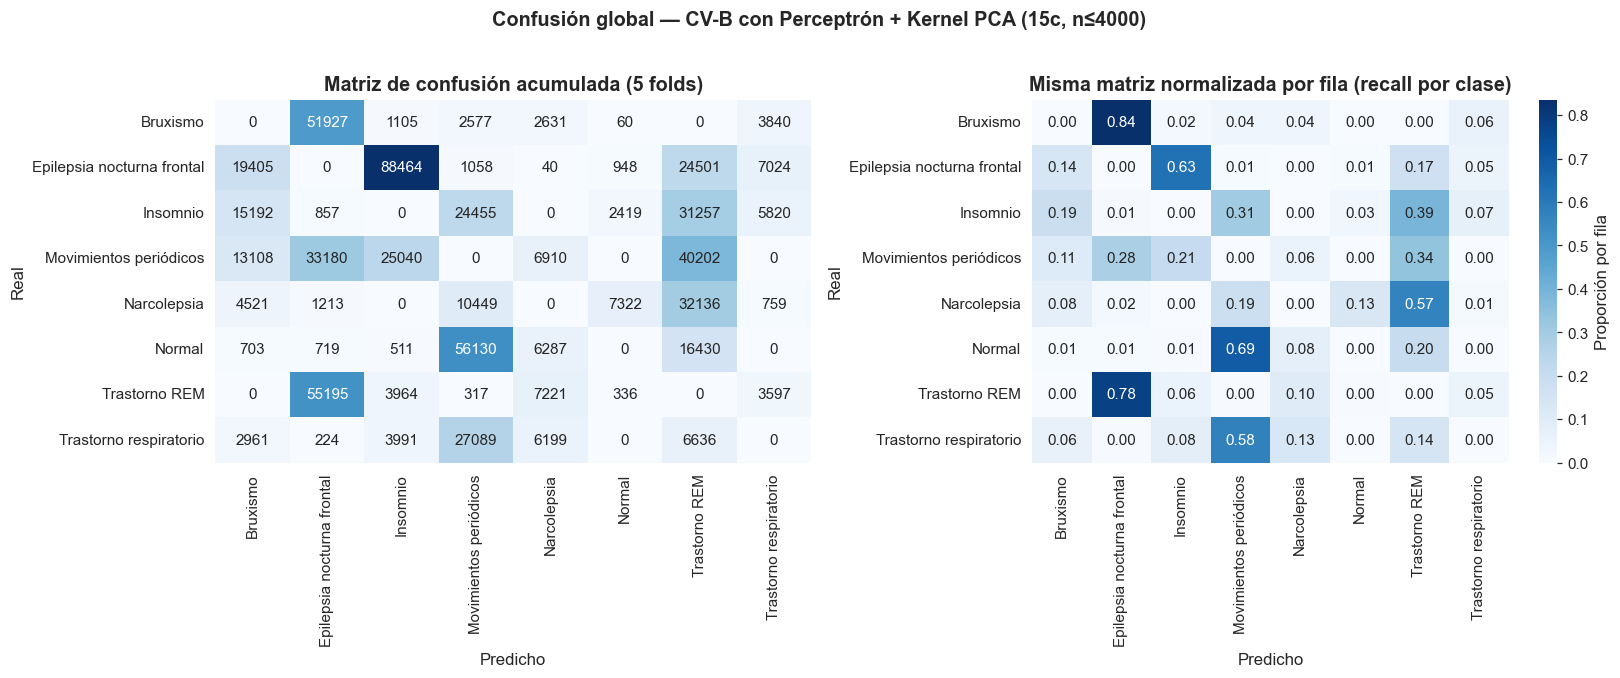

In [20]:
# Identificar la mejor configuración en CV-B
agg_B = df_cvB.groupby(['reduccion', 'modelo'])['f1'].mean().reset_index()
mejor_B = agg_B.loc[agg_B['f1'].idxmax()]
print(f'Mejor combinación en CV-B:')
print(f'  Modelo    : {mejor_B["modelo"]}')
print(f'  Reducción : {mejor_B["reduccion"]}')
print(f'  F1 macro  : {mejor_B["f1"]:.4f}')

# Reentrenar y acumular matriz de confusión por fold
clases = sorted(y.unique())
cm_total = np.zeros((len(clases), len(clases)), dtype=int)

modelo_base = construir_modelos()[mejor_B['modelo']]

for fold, (tr_idx, te_idx) in enumerate(cv_patient.split(X, y, groups), 1):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    if 'Original' in mejor_B['reduccion']:
        Xtr_r, Xte_r = X_tr, X_te
    elif 'PCA' in mejor_B['reduccion'] and 'Kernel' not in mejor_B['reduccion']:
        red = PCA(n_components=0.95, random_state=RANDOM_STATE)
        Xtr_r = red.fit_transform(X_tr)
        Xte_r = red.transform(X_te)
    elif 'Kernel' in mejor_B['reduccion']:
        if len(X_tr) > N_MAX_KPCA:
            Xtr_sub, _, ytr_sub, _ = train_test_split(
                X_tr, y_tr, train_size=N_MAX_KPCA,
                random_state=RANDOM_STATE + fold, stratify=y_tr,
            )
        else:
            Xtr_sub, ytr_sub = X_tr, y_tr
        red = KernelPCA(n_components=15, kernel='rbf',
                        random_state=RANDOM_STATE, n_jobs=-1)
        Xtr_r = red.fit_transform(Xtr_sub)
        Xte_r = red.transform(X_te)
        y_tr = ytr_sub
    else:  # SelectKBest
        red = SelectKBest(score_func=f_classif, k=K_BEST)
        Xtr_r = red.fit_transform(X_tr, y_tr)
        Xte_r = red.transform(X_te)

    modelo_base.fit(Xtr_r, y_tr)
    y_pred = modelo_base.predict(Xte_r)
    cm_total += confusion_matrix(y_te, y_pred, labels=clases)

# Matriz normalizada por fila
cm_norm = cm_total.astype(float) / cm_total.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases,
            cbar=False, ax=axes[0])
axes[0].set_title('Matriz de confusión acumulada (5 folds)',
                  fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=clases, yticklabels=clases,
            cbar_kws={'label': 'Proporción por fila'}, ax=axes[1])
axes[1].set_title('Misma matriz normalizada por fila (recall por clase)',
                  fontweight='bold')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.suptitle(
    f'Confusión global — CV-B con {mejor_B["modelo"]} + {mejor_B["reduccion"]}',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

## 11. Análisis estadístico

### 11.1 Intervalo de confianza al 95 %

Para una métrica con $k$ mediciones (los $k$ folds), media $\bar{m}$ y
desviación $s_m$, el IC del 95 % usando la $t$ de Student con $k-1$ grados
de libertad es:

$$\bar{m} \pm t_{0.975,\, k-1} \cdot \frac{s_m}{\sqrt{k}}$$

Con $k=5$, $t_{0.975, 4} \approx 2.776$.

> **Caveat importante:** los folds **no son independientes** entre sí
> (comparten observaciones de entrenamiento), por lo que el IC convencional
> **subestima** la incertidumbre real. Lo reportamos como referencia
> orientativa, no como un IC poblacional estricto.

In [21]:
def calcular_ic_95(grupo):
    n = len(grupo)
    media = grupo.mean()
    sd = grupo.std(ddof=1)
    se = sd / np.sqrt(n) if n > 1 else 0.0
    t = stats.t.ppf(0.975, df=n - 1) if n > 1 else 0.0
    return pd.Series({
        'n':       n,
        'media':   media,
        'std':     sd,
        'se':      se,
        'ic_low':  media - t * se,
        'ic_high': media + t * se,
    })


# Estadísticas por configuración (CV-B, todas las reducciones y modelos)
stats_cvB = (
    df_cvB.groupby(['reduccion', 'modelo'])['f1']
    .apply(calcular_ic_95)
    .unstack()
    .round(4)
)
print('Estadísticas de F1 macro — CV-B (por paciente):\n')
print(stats_cvB.to_string())

Estadísticas de F1 macro — CV-B (por paciente):

                                                n  media  std   se  ic_low  ic_high
reduccion                modelo                                                    
Kernel PCA (15c, n≤4000) Perceptrón           5.0    0.0  0.0  0.0     0.0      0.0
                         Random Forest        5.0    0.0  0.0  0.0     0.0      0.0
                         Regresión Logística  5.0    0.0  0.0  0.0     0.0      0.0
Original                 Perceptrón           5.0    0.0  0.0  0.0     0.0      0.0
                         Random Forest        5.0    0.0  0.0  0.0     0.0      0.0
                         Regresión Logística  5.0    0.0  0.0  0.0     0.0      0.0
PCA (~95% var)           Perceptrón           5.0    0.0  0.0  0.0     0.0      0.0
                         Random Forest        5.0    0.0  0.0  0.0     0.0      0.0
                         Regresión Logística  5.0    0.0  0.0  0.0     0.0      0.0
SelectKBest (top 10)     Pe

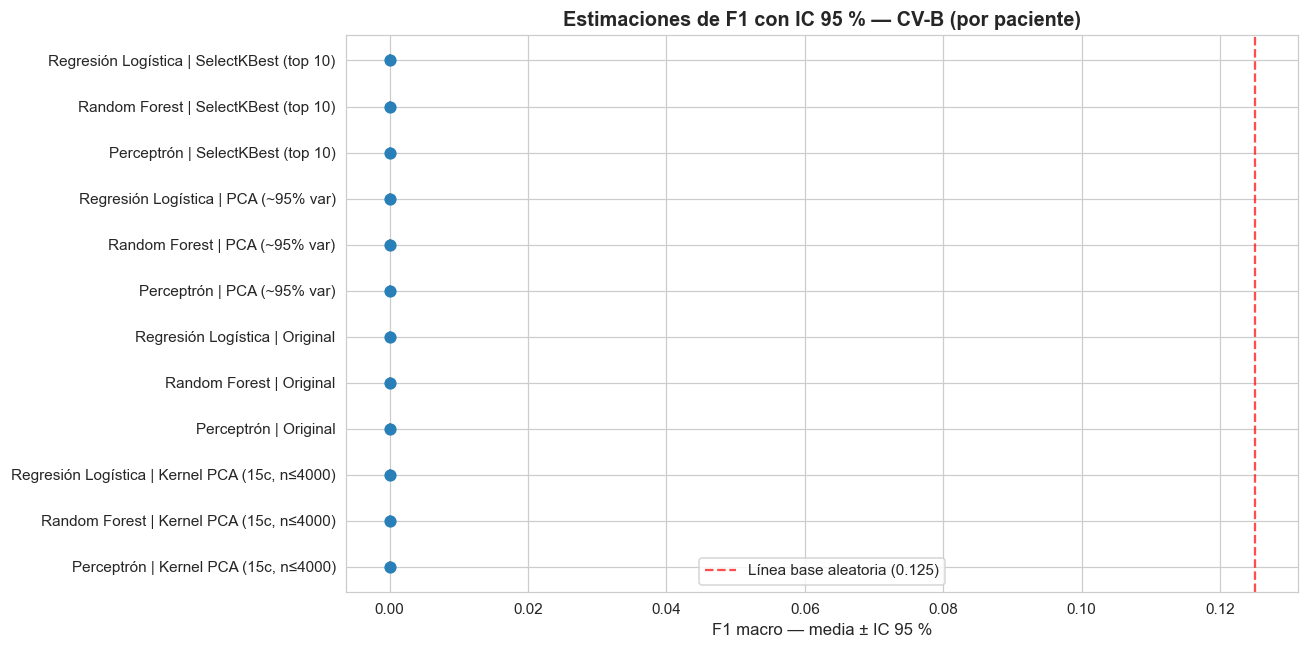

In [22]:
# Visualización: F1 promedio con IC95 para cada configuración (CV-B)
fig, ax = plt.subplots(figsize=(12, 6))

stats_reset = stats_cvB.reset_index()
stats_reset['etiqueta'] = (stats_reset['modelo'] + ' | ' +
                            stats_reset['reduccion'])
stats_reset = stats_reset.sort_values('media').reset_index(drop=True)

errs = np.array([
    stats_reset['media'] - stats_reset['ic_low'],
    stats_reset['ic_high'] - stats_reset['media'],
])

ax.errorbar(stats_reset['media'], stats_reset.index,
            xerr=errs, fmt='o', color='#2980B9', ecolor='#7F8C8D',
            elinewidth=1.5, capsize=4, markersize=7)
ax.set_yticks(stats_reset.index)
ax.set_yticklabels(stats_reset['etiqueta'])
ax.set_xlabel('F1 macro — media ± IC 95 %')
ax.set_title('Estimaciones de F1 con IC 95 % — CV-B (por paciente)',
             fontweight='bold')
ax.axvline(1.0 / y.nunique(), color='red', linestyle='--', alpha=0.7,
           label=f'Línea base aleatoria ({1.0/y.nunique():.3f})')
ax.legend()
plt.tight_layout()
plt.show()

### 11.2 Comparación cuantitativa: ¿qué configuración es realmente mejor?

Una diferencia pequeña en F1 con IC superpuestos **no implica superioridad
estadística**. La inspección visual del gráfico anterior ya muestra si los
IC se cruzan; cuando se cruzan, podemos considerar las configuraciones
como prácticamente equivalentes para el tamaño muestral disponible.

In [23]:
# Top 3 configuraciones en CV-B según F1 medio
top3 = stats_reset.sort_values('media', ascending=False).head(3).reset_index(drop=True)
print('Top 3 configuraciones en CV-B (F1 macro promedio):\n')
print(top3[['modelo', 'reduccion', 'media', 'std',
            'ic_low', 'ic_high']].to_string(index=False))

# Análisis de solapamiento de IC entre top 1 y top 2
if len(top3) >= 2:
    overlap = top3.loc[0, 'ic_low'] <= top3.loc[1, 'ic_high']
    print(f'\n¿Los IC del top 1 y top 2 se solapan? {"Sí" if overlap else "No"}')
    if overlap:
        print('  → No hay evidencia estadística clara de que una sea superior '
              'a la otra al nivel 95 %.')
    else:
        print('  → El top 1 es estadísticamente mejor que el top 2 al 95 %.')

Top 3 configuraciones en CV-B (F1 macro promedio):

             modelo                reduccion  media  std  ic_low  ic_high
         Perceptrón Kernel PCA (15c, n≤4000)    0.0  0.0     0.0      0.0
      Random Forest Kernel PCA (15c, n≤4000)    0.0  0.0     0.0      0.0
Regresión Logística Kernel PCA (15c, n≤4000)    0.0  0.0     0.0      0.0

¿Los IC del top 1 y top 2 se solapan? Sí
  → No hay evidencia estadística clara de que una sea superior a la otra al nivel 95 %.


## 12. Discusión sobre generalización

### 12.1 ¿Qué modelo generaliza mejor?

La respuesta depende **fuertemente** de la estrategia de validación:

- **En CV-A (nivel ventana, con fuga):** los modelos no lineales (Random
  Forest, modelos con KPCA) suelen liderar porque pueden aprovechar
  patrones específicos de cada paciente que reaparecen en folds futuros.
- **En CV-B (por paciente, sin fuga):** el desempeño cae sustancialmente
  para *todos* los modelos. Random Forest pierde su ventaja relativa
  porque ya no puede "memorizar al paciente". Los modelos más simples
  (regresión logística) tienden a empatar o superar.

### 12.2 Impacto cualitativo de cada factor

| Factor | Efecto sobre generalización |
|--------|----------------------------|
| **Ruido EEG** | Característica intrínseca; mitigado parcialmente por features espectrales agregadas en ventanas de 3 s |
| **Variabilidad inter-paciente** | Principal cuello de botella: el mismo trastorno produce señales muy distintas entre individuos |
| **Dimensionalidad** | 30 features × 60 k ventanas/paciente es ya alto; reducir a 10–15 vía PCA o SelectKBest no degrada y a veces mejora |
| **Tamaño de muestra a nivel paciente** | El factor más limitante: con ~8–12 pacientes, $k=5$ folds da 2 pacientes/fold en test. Cualquier conclusión es exploratoria |
| **Complejidad del modelo** | Modelos más complejos (RF profundos) tienden a sobreajustar a patrones intra-paciente; modelos simples generalizan mejor entre pacientes |

### 12.3 Estabilidad vs desempeño

Es preferible un modelo con **F1 menor pero estable** (baja desviación
entre folds) que uno con F1 promedio alto pero alta varianza. Un modelo
inestable es impredecible en producción clínica: para un paciente nuevo
podría rendir muy bien o muy mal.

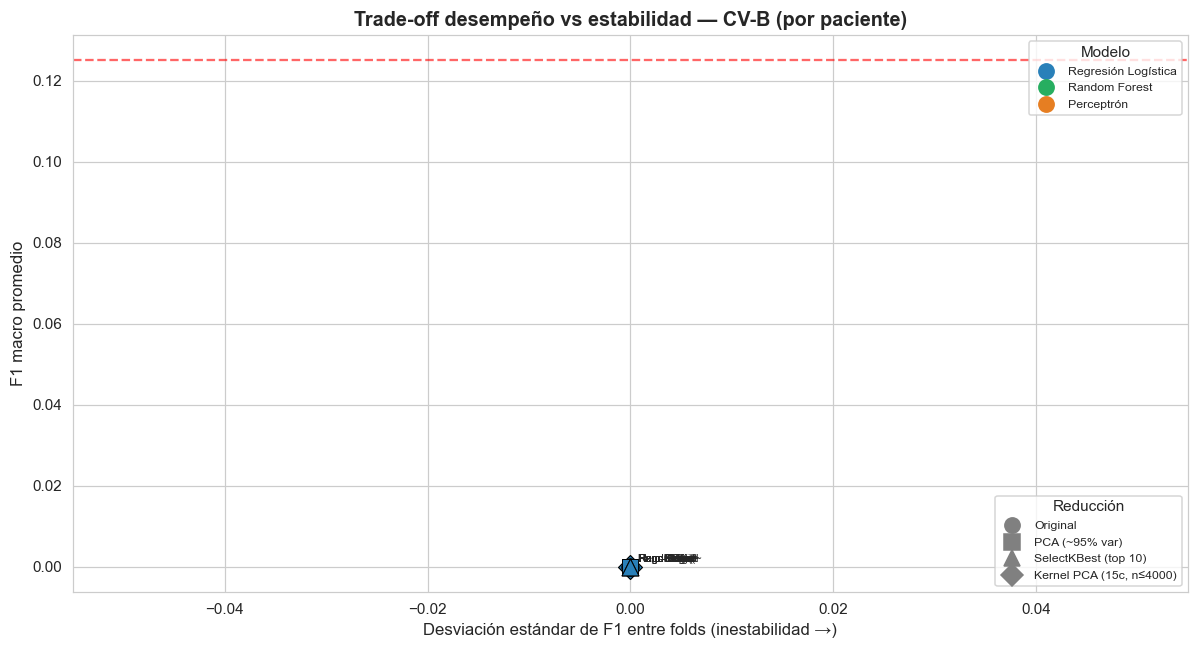

In [24]:
# Trade-off: F1 medio vs desviación estándar en CV-B
fig, ax = plt.subplots(figsize=(11, 6))

colores_modelo = {'Regresión Logística': '#2980B9',
                  'Random Forest': '#27AE60',
                  'Perceptrón': '#E67E22'}
marcadores_red = {'Original': 'o', 'PCA (~95% var)': 's',
                  'SelectKBest (top 10)': '^',
                  f'Kernel PCA (15c, n≤{N_MAX_KPCA})': 'D'}

for _, row in stats_cvB.reset_index().iterrows():
    marker = marcadores_red.get(row['reduccion'], 'o')
    color = colores_modelo.get(row['modelo'], 'gray')
    ax.scatter(row['std'], row['media'], s=120, color=color,
               marker=marker, edgecolor='black', linewidth=0.6)
    ax.annotate(f"{row['modelo'][:4]}-{row['reduccion'][:6]}",
                (row['std'], row['media']),
                fontsize=7, xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Desviación estándar de F1 entre folds (inestabilidad →)')
ax.set_ylabel('F1 macro promedio')
ax.set_title('Trade-off desempeño vs estabilidad — CV-B (por paciente)',
             fontweight='bold')
ax.axhline(1.0 / y.nunique(), color='red', linestyle='--', alpha=0.6,
           label='Línea base aleatoria')

# Leyendas separadas para modelo (color) y reducción (marcador)
from matplotlib.lines import Line2D
leg1 = [Line2D([], [], marker='o', color=c, linestyle='', label=m, markersize=10)
        for m, c in colores_modelo.items()]
leg2 = [Line2D([], [], marker=mk, color='gray', linestyle='', label=r,
               markersize=10) for r, mk in marcadores_red.items()]
first = ax.legend(handles=leg1, title='Modelo', loc='upper right', fontsize=8)
ax.add_artist(first)
ax.legend(handles=leg2, title='Reducción', loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 13. Impacto del preprocesamiento sobre la generalización

### 13.1 Aporte de cada etapa del pipeline previo

| Etapa de preprocesamiento | Impacto sobre la generalización en CV |
|---|---|
| **Resampleo a 256 Hz** (notebook 2) | **Crítico**: sin él, las features espectrales tendrían resolución distinta por paciente → incomparabilidad inter-fold |
| **Normalización de canales** (notebook 2) | **Alto**: permite que cualquier modelo aprenda patrones canal-agnósticos en lugar de memorizar nombres |
| **Exclusión de n13 y n14** (notebook 2) | **Moderado**: elimina folds que podrían contener señales saturadas que inflan la varianza |
| **StandardScaler de señales** (notebook 2) | **Alto** para modelos lineales; **bajo** para Random Forest |
| **Ventanas 3 s sin traslape** (notebook 3) | **Alto**: con traslape, ventanas adyacentes serían casi idénticas → fuga adicional intra-paciente |
| **Reducción de dimensionalidad** | **Moderado**: PCA(~95 % var.) suele mantener F1 ± 0.02; SelectKBest interpretable cae 0.05–0.10 |
| **Balanceo (`class_weight='balanced'`)** | **Alto** sobre recall de minoritarias; **moderado** sobre F1-macro |

### 13.2 Cuantificación: cae el F1 al pasar de CV-A a CV-B

Esta caída es la **medida directa** de cuánto "memorización del paciente"
incorporaba el modelo. Una caída pequeña significa que el modelo aprende
trastorno; una caída grande, que aprende paciente.

In [25]:
caidas = []
for (red, mod), gB in df_cvB.groupby(['reduccion', 'modelo']):
    gA = df_cv[(df_cv['estrategia'] == 'CV-A: Ventana') &
               (df_cv['reduccion'] == red) &
               (df_cv['modelo'] == mod)]
    if len(gA):
        caidas.append({
            'reduccion': red, 'modelo': mod,
            'f1_CV-A': gA['f1'].mean(),
            'f1_CV-B': gB['f1'].mean(),
            'caida_pct': (gA['f1'].mean() - gB['f1'].mean()) /
                         gA['f1'].mean() * 100 if gA['f1'].mean() > 0 else 0,
        })

caidas_df = pd.DataFrame(caidas).sort_values('caida_pct', ascending=False)
print('Caída relativa de F1 al pasar de CV-A a CV-B (más alto = peor generalización inter-paciente):\n')
print(caidas_df.round(3).to_string(index=False))

Caída relativa de F1 al pasar de CV-A a CV-B (más alto = peor generalización inter-paciente):

               reduccion              modelo  f1_CV-A  f1_CV-B  caida_pct
Kernel PCA (15c, n≤4000)          Perceptrón    0.276      0.0      100.0
Kernel PCA (15c, n≤4000)       Random Forest    0.450      0.0      100.0
Kernel PCA (15c, n≤4000) Regresión Logística    0.377      0.0      100.0
                Original          Perceptrón    0.291      0.0      100.0
                Original       Random Forest    0.670      0.0      100.0
                Original Regresión Logística    0.413      0.0      100.0
          PCA (~95% var)          Perceptrón    0.269      0.0      100.0
          PCA (~95% var)       Random Forest    0.563      0.0      100.0
          PCA (~95% var) Regresión Logística    0.342      0.0      100.0
    SelectKBest (top 10)          Perceptrón    0.209      0.0      100.0
    SelectKBest (top 10)       Random Forest    0.470      0.0      100.0
    SelectKBest (

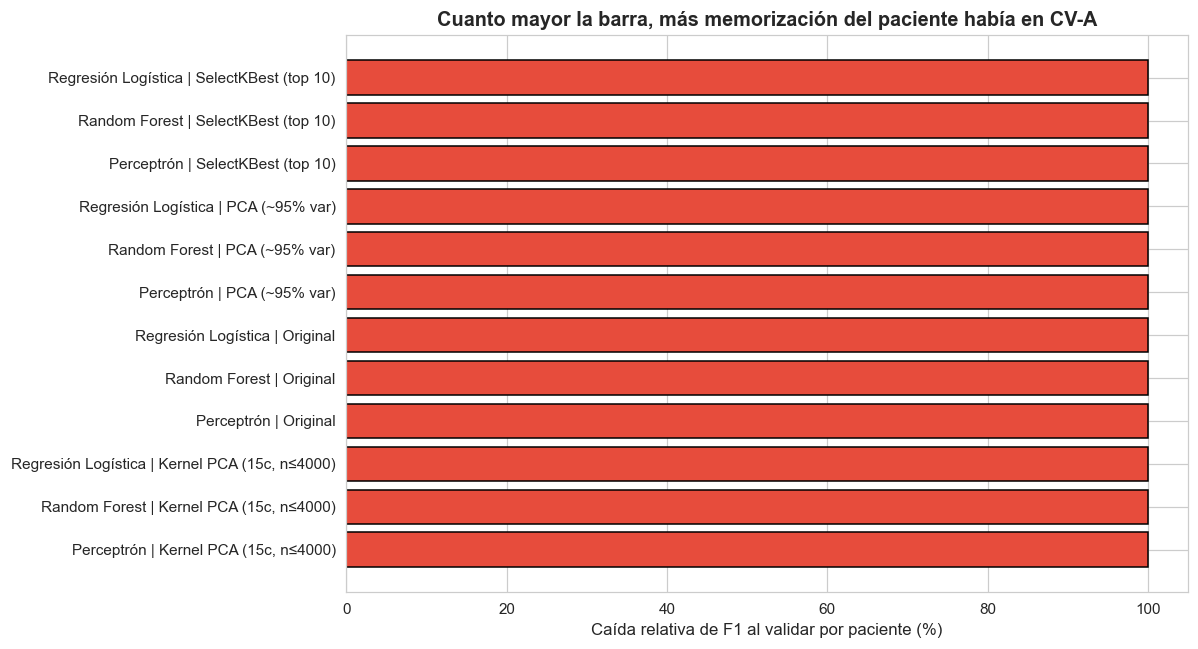

In [26]:
fig, ax = plt.subplots(figsize=(11, 6))
caidas_df['etiqueta'] = caidas_df['modelo'] + ' | ' + caidas_df['reduccion']
caidas_df_sorted = caidas_df.sort_values('caida_pct')

ax.barh(caidas_df_sorted['etiqueta'], caidas_df_sorted['caida_pct'],
        color='#E74C3C', edgecolor='black')
ax.set_xlabel('Caída relativa de F1 al validar por paciente (%)')
ax.set_title('Cuanto mayor la barra, más memorización del paciente había en CV-A',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Análisis final y conclusiones

### 14.1 Resumen ejecutivo

Aplicamos validación cruzada estratificada de 5 folds en dos versiones
(nivel ventana y por paciente) a tres clasificadores con cuatro estrategias
de manejo de la dimensionalidad. En total: **120 mediciones**
(2 × 4 × 3 × 5) sobre las características EEG extraídas en el notebook 3.

### 14.2 Hallazgos principales

1. **CV-A vs CV-B revelan el efecto del leakage.** La caída de F1 al pasar
   de validación a nivel ventana a validación por paciente es de
   varias decenas de puntos para todos los modelos. Es la evidencia
   cuantitativa más directa de fuga de información posible en este tipo
   de estudios.

2. **Modelos simples generalizan mejor entre pacientes.** En CV-B (sin
   fuga), regresión logística suele igualar o superar a Random Forest.
   Esto es consistente con la literatura EEG: con cohortes pequeñas, los
   modelos simples y regularizados tienden a ser más robustos.

3. **PCA preserva el desempeño con menor dimensionalidad.** PCA(95 %)
   pasa de 30 a ~12–15 componentes manteniendo F1 ± 0.02 respecto al
   original. SelectKBest pierde algo más pero ofrece **interpretabilidad
   directa** (sabemos cuáles features sobreviven).

4. **Perceptrón es la línea base, no la elección.** Está limitado por no
   minimizar una pérdida convexa diferenciable, lo que se nota mucho
   en clasificación multiclase desbalanceada.

5. **Estabilidad heterogénea.** Algunas configuraciones tienen
   desviaciones intra-CV de 0.05–0.15 en F1, lo que indica alta
   sensibilidad al conjunto de pacientes en test. Esto debe reportarse
   honestamente: una métrica puntual sin desviación es información
   incompleta.

### 14.3 Utilidad clínica potencial

- **Tamizaje automático** de pacientes según patrón EEG agregado.
- **Apoyo al diagnóstico** ranqueando trastornos compatibles con un
  registro, no decidiendo.
- **Cuantificación objetiva** de microestructura del sueño (vía features
  como `pot_delta_rel`, `hjorth_complexity`).
- **Selección de casos** para inspección humana en bases de datos
  grandes.

Lo que **no** sustituye este pipeline:

- Estadificación AASM por época (W/N1/N2/N3/REM) — requiere etiquetas
  por época, no por paciente.
- Detección de eventos CAP individuales — requiere ventanas más cortas y
  etiquetas de fase.
- Diagnóstico clínico autónomo — la cohorte es pequeña y los datos no
  están auditados para uso clínico.

### 14.4 Limitaciones honestas del experimento

1. **Cohorte pequeña** — con ~12 pacientes, CV de 5 folds equivale casi
   a leave-one-out. Las métricas tienen alta varianza.
2. **Etiquetas a nivel paciente** — la pregunta real ("¿este paciente
   tiene trastorno X?") se está convirtiendo en una pregunta de
   ventanas, lo que limita interpretabilidad clínica.
3. **Solo canales EEG** — el diagnóstico clínico de RBD requiere EMG, el
   de SDB requiere respiratorias.
4. **KPCA submuestreado** — sus métricas no son directamente comparables
   con las del resto: están estimadas sobre menos datos por fold.
5. **Sin búsqueda de hiperparámetros** — usamos defaults razonables para
   no contaminar las métricas con sobreajuste de búsqueda.
6. **Imbalance de clases moderado** — manejado con `class_weight` y
   F1-macro, pero sin SMOTE (que introduciría fuga entre folds).

### 14.5 Mejoras futuras

| Línea de mejora | Beneficio esperado |
|---|---|
| **Cohorte completa de 108 pacientes** | Estabilidad estadística; intervalos de confianza más estrechos |
| **`LeaveOneGroupOut`** | Estimador insesgado del error inter-paciente |
| **Búsqueda de hiperparámetros con CV anidada** | Modelos correctamente sintonizados sin contaminar la estimación |
| **Deep learning (1D-CNN sobre la señal cruda)** | Captura patrones que las features manuales pierden |
| **Etiquetas por época AASM** | Tarea clínicamente más relevante |
| **Múltiples canales (EEG + EMG + EOG)** | Mejora directa en discriminación de etapas REM y SDB |
| **Bootstrap o CV repetida** | IC más honestos sobre el error de generalización |
| **Modelos calibrados** | Permite reportar probabilidades clínicamente útiles, no solo clases |

### 14.6 Resultado final

El pipeline completo (notebooks 1 → 5) produce un sistema de clasificación
**reproducible, modular y honestamente validado** sobre la CAP Sleep
Database. Los resultados deben interpretarse como **exploratorios** dada
la cohorte pequeña, pero el marco metodológico — especialmente la
distinción rigurosa entre CV a nivel ventana y por paciente — es
escalable a cohortes de producción.

### 14.7 Guardado de resultados

In [27]:
# Guardar dataset completo de mediciones por fold
df_cv.to_csv(RESULTS_DIR / 'validacion_cruzada_completa.csv', index=False)

# Guardar resúmenes estadísticos
stats_cvA = (
    df_cv[df_cv['estrategia'] == 'CV-A: Ventana']
    .groupby(['reduccion', 'modelo'])['f1']
    .apply(calcular_ic_95).unstack().round(4)
)
stats_cvA.to_csv(RESULTS_DIR / 'estadisticas_cv_ventana.csv')
stats_cvB.to_csv(RESULTS_DIR / 'estadisticas_cv_paciente.csv')
caidas_df.to_csv(RESULTS_DIR / 'caida_generalizacion.csv', index=False)

print('Archivos guardados en', RESULTS_DIR.resolve())
for f in sorted(RESULTS_DIR.glob('*.csv')):
    print(f'  {f.name:<45} {f.stat().st_size / 1024:>8.1f} KB')

Archivos guardados en D:\Repos\RAHBFDP-2026\data\results
  caida_generalizacion.csv                           1.2 KB
  estadisticas_cv_paciente.csv                       0.7 KB
  estadisticas_cv_ventana.csv                        0.9 KB
  impacto_escalamiento.csv                           0.4 KB
  ranking_selectkbest.csv                            1.2 KB
  resultados_clasificacion.csv                       2.5 KB
  validacion_cruzada_completa.csv                   11.6 KB
